In [1]:
from limited_data_experiment import do_experiment, ALL_RUNS, EPSGREEDY_EXPECTATION, top_1_normalized_score, top_eps_accuracy
from itertools import count
import multiprocessing as mp
from functools import partial

GAMMA_VALS = [0.05, 0.1, 0.5, 1]
EPS_VALS = [0, 0.1, 0.5, 0.9]

experiment_setups = []
for seq_id in ALL_RUNS:
    for gamma in GAMMA_VALS:
        for eps in EPS_VALS:
            experiment_setups.append(
                {
                    "incremental_learning": True,
                    "one_decision": False,
                    "seq_id": seq_id,
                    "gamma": gamma,
                    "eps": eps,
                    "batch_size": 128,
                }
            )

    for one_decision in [False, True]:
        experiment_setups.append(
            {
                "incremental_learning": False,
                "one_decision": one_decision,
                "seq_id": seq_id,
                "gamma": 1,
                "eps": 0,
                "batch_size": 128,
            }
        )

cnt = count()
for experiment in experiment_setups:
    experiment["experiment_idx"] = next(cnt)
    experiment["experiments_total"] = len(experiment_setups)

num_processes = mp.cpu_count()
print(f"{num_processes = }")
with mp.Pool(num_processes) as pool:
    results = pool.map(partial(do_experiment, dir="../stats/"), experiment_setups)

# results = [do_experiment(x, dir="../stats/") for x in experiment_setups]

/home/porepy/porepy/src/porepy/numerics/nonlinear/nonlinear_solvers.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange  # type: ignore


num_processes = 16
Start experiment 16 / 90Start experiment 8 / 90Start experiment 0 / 90Start experiment 10 / 90

Start experiment 22 / 90


Start experiment 2 / 90Start experiment 14 / 90
Start experiment 28 / 90
Start experiment 18 / 90
Start experiment 12 / 90Start experiment 20 / 90Start experiment 6 / 90



Start experiment 30 / 90
Start experiment 24 / 90Start experiment 4 / 90

Start experiment 26 / 90
Done experiment 16 / 90
Start experiment 17 / 90
Done experiment 0 / 90
Done experiment 18 / 90
Done experiment 20 / 90
Done experiment 22 / 90
Start experiment 1 / 90
Done experiment 2 / 90
Start experiment 19 / 90
Done experiment 4 / 90
Start experiment 21 / 90
Start experiment 23 / 90
Start experiment 3 / 90
Done experiment 6 / 90
Start experiment 5 / 90
Done experiment 8 / 90
Start experiment 7 / 90
Done experiment 24 / 90
Start experiment 9 / 90
Done experiment 10 / 90
Done experiment 26 / 90
Start experiment 25 / 90
Done experiment 17 / 90
Start experiment 11 / 90
Start exp

In [2]:
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib

matplotlib.rcdefaults()

# tex_fonts = {
#     # Use LaTeX to write all text
#     # "text.usetex": True,
#     "font.family": "serif",
#     "axes.labelsize": 10,
#     "font.size": 10,
#     # Make the legend/label fonts a little smaller
#     "legend.fontsize": 9,
#     "xtick.labelsize": 9,
#     "ytick.labelsize": 9,
# }

# sns.set_theme(
#     # context="talk",
#     context="paper",
#     # rc={"figure.figsize": (8, 6)},
#     # palette="colorblind6",
#     style="whitegrid",
#     rc=tex_fonts,
# )

In [3]:
from collections import defaultdict
import numpy as np
import pandas as pd


data_for_pandas = defaultdict(lambda: [])
for result in results:
    data_for_pandas["incremental_learning"].append(result["incremental_learning"])
    data_for_pandas["one_decision"].append(result["one_decision"])
    data_for_pandas["seq_id"].append(result["seq_id"])
    data_for_pandas["gamma"].append(result["gamma"])
    data_for_pandas["eps"].append(result["eps"])
    data_for_pandas["batch_size"].append(result["batch_size"])
    data_for_pandas["NTS"].append((result["NTS"]))
    data_for_pandas["TopEPS"].append((result["TopEPS"]))
    data_for_pandas["mean_NTS"].append(np.mean(result["NTS"]))
    data_for_pandas["mean_TopEPS"].append(np.mean(result["TopEPS"]))
    data_for_pandas['ypred'].append(result['ypred'])
    data_for_pandas['yoracle'].append(result['yoracle'])
    data_for_pandas['yfeedback'].append(result['yfeedback'])
    data_for_pandas['tpred'].append(result['tpred'])
    data_for_pandas['tfeedback'].append(result['tfeedback'])
    data_for_pandas['decision_id'].append(result['decision_id'])


df = pd.DataFrame(data_for_pandas)
df

,incremental_learning,one_decision,seq_id,gamma,eps,batch_size,NTS,TopEPS,mean_NTS,mean_TopEPS,ypred,yoracle,yfeedback,tpred,tfeedback,decision_id
0,True,False,R30,0.05,0.0,128,"[0.7348528664210126, 0.7348528664210126, 0.734...","[False, False, False, False, False, False, Fal...",0.777311,0.000000,"[-0.21219174027491036, -0.21219174027491036, -...","[-0.22444123499570592, -0.22444123499570592, -...","[-0.4323696314709763, -0.4323696314709763, -0....","[0.0018160343170166016, 0.0014095306396484375,...","[2.384185791015625e-06, 1.9073486328125e-06, 1...","[1010, 1010, 1010, 524, 1009, 1009, 1009, 1009..."
1,True,False,R30,0.05,0.1,128,"[0.7348528664210121, 0.7348528664210121, 0.734...","[False, False, False, False, False, False, Fal...",0.879399,0.701344,"[-0.19150432904391254, -0.19150432904391254, -...","[-0.22444123499570587, -0.22444123499570587, -...","[-0.43236963147097635, -0.43236963147097635, -...","[0.001485586166381836, 0.0014026165008544922, ...","[1.1920928955078125e-06, 7.152557373046875e-07...","[1010, 1010, 1010, 1013, 1012, 1012, 87, 1012,..."
2,True,False,R30,0.05,0.5,128,"[0.8913787054760542, -1.0, 0.8375520795298133,...","[False, False, False, False, False, False, Fal...",0.891656,0.626488,"[100.0, 100.0, 100.0, 100.0, -0.22263436040060...","[-0.22444123499570595, -0.22444123499570595, -...","[-0.3096220600288526, -100.0, -0.3518329030034...","[8.320808410644531e-05, 3.552436828613281e-05,...","[2.1457672119140625e-06, 1.6689300537109375e-0...","[860, 1044, 466, 87, 1012, 130, 769, 1012, 994..."
3,True,False,R30,0.05,0.9,128,"[0.8913787054760545, -1.0, 0.8375520795298135,...","[False, False, False, False, False, False, Fal...",0.906293,0.471401,"[100.0, 100.0, 100.0, 100.0, 100.0, -0.2307973...","[-0.22444123499570603, -0.22444123499570603, -...","[-0.3096220600288527, -100.0, -0.3518329030034...","[3.933906555175781e-05, 3.337860107421875e-05,...","[1.6689300537109375e-06, 1.1920928955078125e-0...","[860, 1044, 466, 87, 871, 1012, 769, 1012, 994..."
4,True,False,R30,0.10,0.0,128,"[0.7662533765582906, 0.7662533765582906, 0.766...","[False, False, False, False, False, False, Fal...",0.847341,0.526679,"[-0.1779682513450358, -0.1779682513450358, -0....","[-0.22444123499570595, -0.22444123499570595, -...","[-0.40774534972514037, -0.40774534972514037, -...","[0.0024023056030273438, 0.0019485950469970703,...","[2.6226043701171875e-06, 2.384185791015625e-06...","[763, 763, 763, 763, 763, 763, 763, 763, 763, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,True,False,R34,1.00,0.1,128,"[0.9891536245817685, 0.9891536245817685, 0.988...","[True, True, True, True, True, True, False, Tr...",0.896993,0.789262,"[-0.32801207507267943, -0.32801207507267943, -...","[-0.22351518701457931, -0.22351518701457931, -...","[-0.2318093329976109, -0.2318093329976109, -0....","[0.001758575439453125, 0.0015921592712402344, ...","[1.430511474609375e-06, 9.5367431640625e-07, 7...","[620, 620, 620, 620, 620, 620, 87, 620, 620, 6..."
86,True,False,R34,1.00,0.5,128,"[0.9180221002300368, -1.0, 0.8127210112248882,...","[False, False, False, False, True, False, Fals...",0.968525,0.922571,"[100.0, 100.0, 100.0, 100.0, -0.32704196545921...","[-0.22351518701457937, -0.22351518701457937, -...","[-0.28620310273355, -100.0, -0.361100499747688...","[4.00543212890625e-05, 3.838539123535156e-05, ...","[1.6689300537109375e-06, 1.1920928955078125e-0...","[860, 1044, 466, 87, 620, 130, 769, 620, 620, ..."
87,True,False,R34,1.00,0.9,128,"[0.9180221002300373, -1.0, 0.8127210112248882,...","[False, False, False, False, False, True, Fals...",0.870094,0.709642,"[100.0, 100.0, 100.0, 100.0, 100.0, -0.3215301...","[-0.22351518701457945, -0.22351518701457945, -...","[-0.28620310273354993, -100.0, -0.361100499747...","[3.719329833984375e-05, 3.457069396972656e-05,...","[1.6689300537109375e-06, 9.5367431640625e-07, ...","[860, 1044, 466, 87, 871, 620, 769, 620, 620, ..."
88,False,False,R34,1.00,0.0,128,"[0.9891536245817687, 0.98915362458176

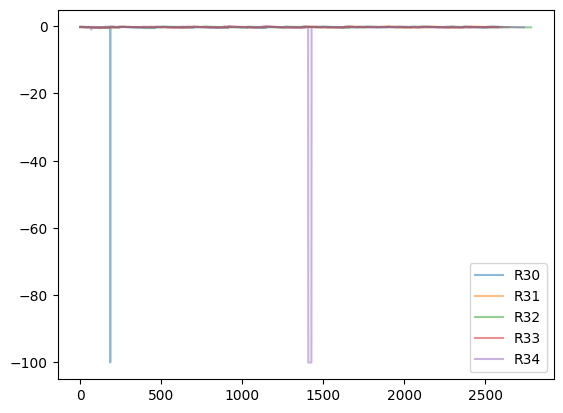

In [4]:
from matplotlib import pyplot as plt

for row in df[(df.eps == 0) & (df.gamma == 1) & (df.incremental_learning) & ~df.one_decision].itertuples(index=False):
    plt.plot((row.yfeedback), label=row.seq_id, alpha=0.5)
plt.legend()


In [5]:
df_heatmap = df[(df.incremental_learning) & ~(df.one_decision)]
# df_heatmap = df_heatmap.groupby(["eps", 'gamma'])["mean_TopEPS"].agg(["mean", 'std']).unstack()
df_heatmap = df_heatmap.groupby(["eps", 'gamma'])["mean_NTS"].agg(["mean", 'std']).unstack()

df_heatmap

mean                                     std                      \
gamma      0.05      0.10      0.50      1.00      0.05      0.10      0.50   
eps                                                                           
0.0    0.886300  0.894592  0.971607  0.960361  0.066016  0.045777  0.020577   
0.1    0.896512  0.908562  0.944787  0.924765  0.032960  0.039855  0.060656   
0.5    0.892939  0.880967  0.945340  0.932982  0.034369  0.096181  0.039375   
0.9    0.898070  0.914196  0.955094  0.913734  0.029660  0.022627  0.011702   

                 
gamma      1.00  
eps              
0.0    0.030396  
0.1    0.036403  
0.5    0.052948  
0.9    0.041569

In [6]:
annot = df_heatmap['mean'].round(2).astype(str) + "±" + df_heatmap['std'].round(2).astype(str)
annot

gamma,0.05,0.10,0.50,1.00
eps,,,,
0.0,0.89±0.07,0.89±0.05,0.97±0.02,0.96±0.03
0.1,0.9±0.03,0.91±0.04,0.94±0.06,0.92±0.04
0.5,0.89±0.03,0.88±0.1,0.95±0.04,0.93±0.05
0.9,0.9±0.03,0.91±0.02,0.96±0.01,0.91±0.04


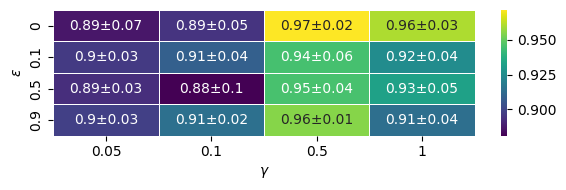

In [7]:
plt.figure(figsize=(6, 2))
sns.heatmap(
    np.array(df_heatmap["mean"]),
    # np.array(df_heatmap["std"]),
    annot=np.array(annot),
    cmap="viridis",
    linecolor="white",
    linewidths=0.5,
    yticklabels=EPS_VALS,
    xticklabels=GAMMA_VALS,
    fmt="",
)
plt.ylabel(r"$\varepsilon$")
plt.xlabel(r"$\gamma$")
# plt.title(r"Top-$\varepsilon$ Acc.", fontweight="bold")
plt.tight_layout()
# plt.savefig("scenarioA_topeps.pdf")

In [8]:
from sklearn.neural_network import MLPRegressor

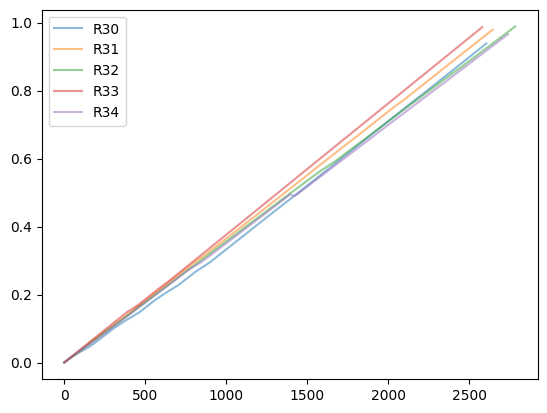

In [9]:
from matplotlib import pyplot as plt

for row in df[(df.eps == 0.) & (df.gamma == 0.5) & (df.incremental_learning) & ~df.one_decision].itertuples(index=False):
    # plt.plot((row.NTS), label=row.seq_id, alpha=0.5)

    # plt.plot(np.cumsum(row.TopEPS) / np.size(row.TopEPS), label=row.seq_id, alpha=0.5)
    plt.plot(np.cumsum(row.NTS) / np.size(row.NTS), label=row.seq_id, alpha=0.5)

plt.legend()


In [10]:
df_special = df[~df.incremental_learning]
df_special = df_special.groupby('one_decision')[["mean_TopEPS", 'mean_NTS']].agg(["mean", 'std'])
df_special

mean_TopEPS            mean_NTS          
                    mean       std      mean       std
one_decision                                          
False           0.395365  0.342593  0.800610  0.316666
True            0.235711  0.333728  0.825986  0.153890

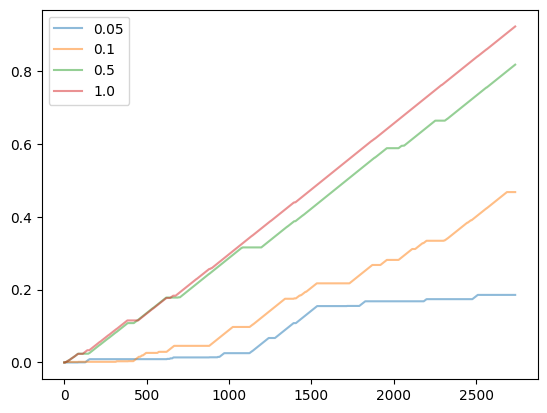

In [11]:
from matplotlib import pyplot as plt

for row in df[(df.eps == 0.5) & (df.seq_id == 'R34') & (df.incremental_learning) & ~df.one_decision].itertuples(index=False):
    plt.plot(np.cumsum(row.TopEPS) / np.size(row.TopEPS), label=row.gamma, alpha=0.5)
    # plt.plot(np.cumsum(row.NTS) / np.size(row.NTS), label=row.gamma, alpha=0.5)

plt.legend()

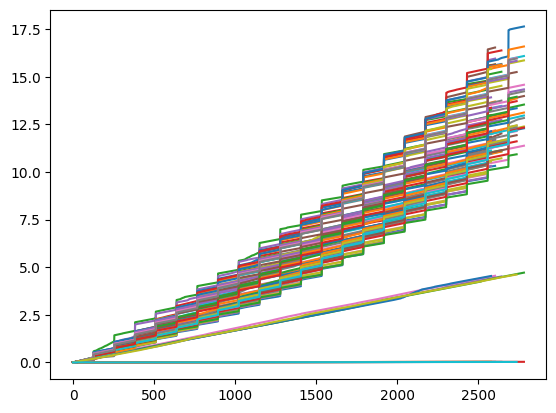

In [15]:
for row in df.itertuples(index=False):
    plt.plot(np.cumsum(row.tfeedback + row.tpred))

In [ ]:
row.__dir__()

['__doc__',
 '__slots__',
 '_fields',
 '_field_defaults',
 '__new__',
 '_make',
 '_replace',
 '__repr__',
 '_asdict',
 '__getnewargs__',
 '__match_args__',
 'incremental_learning',
 'one_decision',
 'seq_id',
 'gamma',
 'eps',
 'batch_size',
 'NTS',
 'TopEPS',
 'mean_NTS',
 'mean_TopEPS',
 'ypred',
 'yoracle',
 'yfeedback',
 'decision_id',
 '__module__',
 '__hash__',
 '__getattribute__',
 '__lt__',
 '__le__',
 '__eq__',
 '__ne__',
 '__gt__',
 '__ge__',
 '__iter__',
 '__len__',
 '__getitem__',
 '__add__',
 '__mul__',
 '__rmul__',
 '__contains__',
 'index',
 'count',
 '__class_getitem__',
 '__str__',
 '__setattr__',
 '__delattr__',
 '__init__',
 '__reduce_ex__',
 '__reduce__',
 '__getstate__',
 '__subclasshook__',
 '__init_subclass__',
 '__format__',
 '__sizeof__',
 '__dir__',
 '__class__']